# Implementación en PyTorch — recurso de la Clase 5

**Módulo 07 — Fundamentos de Deep Learning.** Recurso descargable `OD_RN2_ESP_M02_S05`: una red neuronal que clasifica el dataset **Iris** con PyTorch.

El notebook recorre el flujo completo que plantean las slides de la Clase 4, en el mismo orden: **datos → tensores → lotes → modelo → pérdida y optimizador → entrenamiento → evaluación**. Es el equivalente en PyTorch de lo que en el módulo anterior se hacía con `MLPClassifier` en tres líneas; acá cada paso es explícito, y ese es justamente el punto de la clase.

El notebook original venía sin una sola celda de texto. Las explicaciones se agregaron sin tocar el código ni los outputs.

> **Kernel:** este módulo usa `Python 3.12 (dl-env)`, el entorno con PyTorch y TensorFlow instalados. Ver [`teoria/Configuración del entorno.md`](<../teoria/Configuración del entorno.md>).

> ⚠️ **La celda 10 (el gráfico) está rota en el original.** El diagnóstico y el arreglo están antes de esa celda.

## Qué diferencia a PyTorch de scikit-learn

| | `scikit-learn` (módulo 06) | PyTorch (este notebook) |
|---|---|---|
| Definir el modelo | `MLPClassifier(hidden_layer_sizes=(64,128))` | una clase que hereda de `nn.Module` |
| Entrenar | `.fit(X, y)` | un bucle que se escribe a mano |
| Datos | arrays de NumPy | tensores, servidos por un `DataLoader` |
| Control sobre el proceso | ninguno | total: cada paso del gradiente es visible |

Esa verbosidad no es un capricho: es lo que permite después construir CNNs, RNNs y arquitecturas que `scikit-learn` no puede expresar.

# IRIS

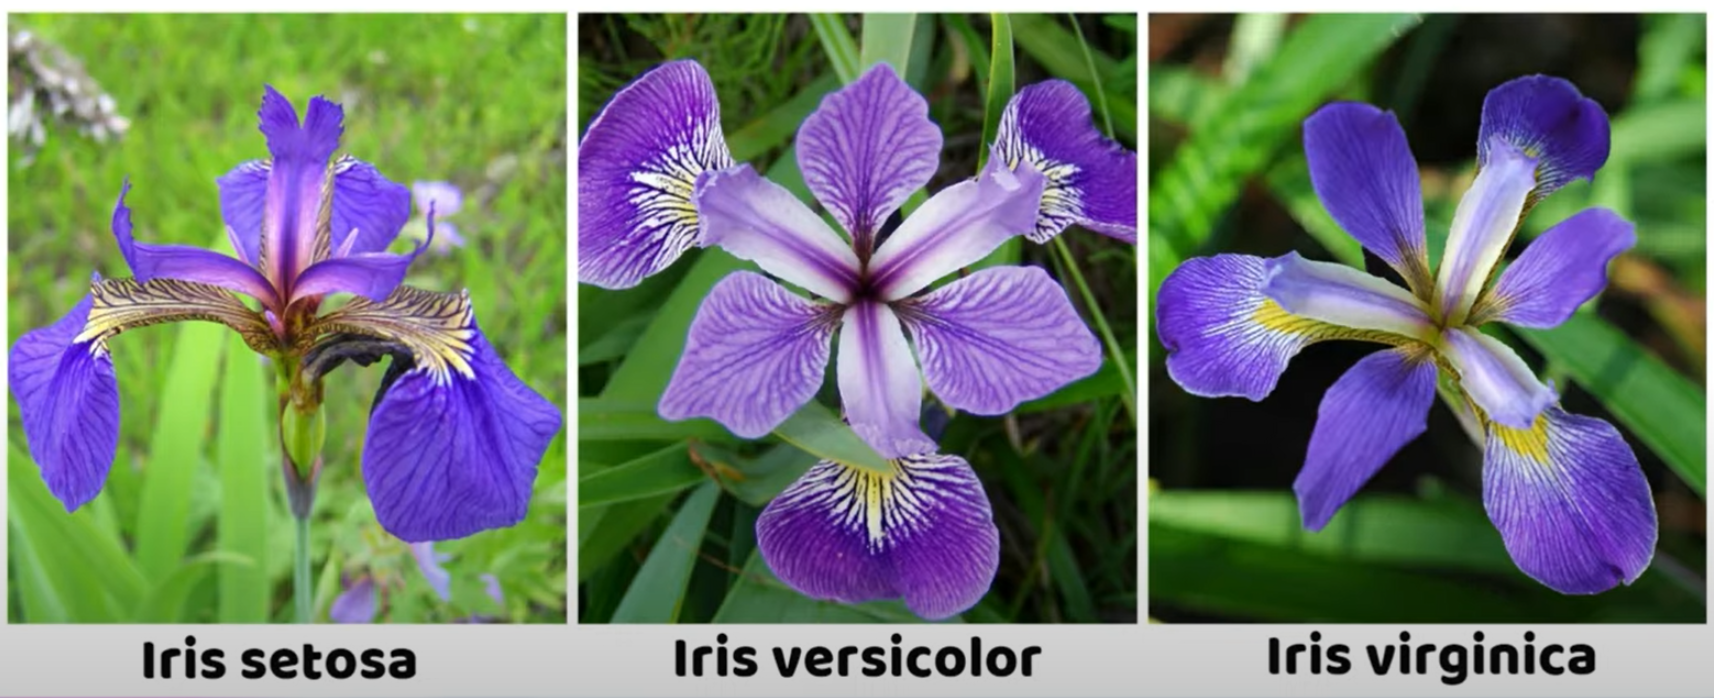

## 1. Librerías

Cada import cumple un rol en el flujo:

| Import | Para qué |
|---|---|
| `torch` | el núcleo: tensores y operaciones matemáticas |
| `torch.nn` | capas (`Linear`) y funciones de pérdida (`CrossEntropyLoss`) |
| `torch.optim` | optimizadores (`Adam`, `SGD`) |
| `DataLoader`, `TensorDataset` | agrupar los datos y servirlos por lotes |
| `load_iris`, `train_test_split`, `StandardScaler` | de scikit-learn: dataset, partición y escalado |
| `matplotlib.pyplot` | la curva de pérdida |

Vale notar que **scikit-learn no desaparece**: se sigue usando para conseguir y preparar los datos. PyTorch se ocupa solo de la red.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

## 2. Los datos

**Iris**: 150 flores, 4 atributos numéricos (largo y ancho de sépalo y pétalo) y 3 especies como etiqueta.

Es el mismo dataset que se usó en el módulo 06 con `MLPClassifier`, y eso es deliberado: permite comparar el resultado de los dos enfoques sobre un terreno conocido. La diferencia es que acá se usan **los 4 atributos**, no dos como en aquellos ejercicios.

`X` queda con la matriz de 150×4 e `y` con el vector de 150 etiquetas, ya codificadas como 0, 1 y 2.

In [ ]:
iris = load_iris()
#iris
X = iris.data
y = iris.target

## 3. División train/test

Partición **80/20** con `random_state=42`, que fija la semilla para que el resultado sea reproducible: sin ella, cada corrida tomaría filas distintas y las métricas no serían comparables entre ejecuciones.

Quedan 120 flores para entrenar y 30 para evaluar. Ese tamaño de test es chico —cada acierto vale 3,3 puntos de exactitud—, así que conviene no leer diferencias de uno o dos aciertos como si fueran significativas.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 4. Escalado

`StandardScaler` transforma cada atributo a media 0 y desvío 1.

El detalle que importa es **cuál se ajusta con qué**:

- `fit_transform(X_train)` — calcula la media y el desvío **con los datos de entrenamiento** y los aplica.
- `transform(X_test)` — aplica esos mismos valores al test, **sin recalcularlos**.

Si se hiciera `fit` sobre el test, sus estadísticas se filtrarían al modelo y las métricas saldrían optimistas: es *data leakage*.

**En redes neuronales el escalado no es opcional.** Con atributos en escalas distintas, las neuronas arrancan saturadas y el gradiente se estanca. En el módulo anterior esto se midió: el mismo MLP pasaba de 58,56% a 99,11% de exactitud solo por escalar.

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 5. De arrays de NumPy a tensores

PyTorch no opera sobre arrays de NumPy sino sobre **tensores**: la misma idea de arreglo multidimensional, pero con dos capacidades extra que son la razón de existir del framework — pueden moverse a la **GPU** y registran las operaciones para calcular gradientes automáticamente (*autograd*).

La conversión explicita el tipo de dato, y no es un detalle menor:

- **`float32` para las features.** Es el tipo con el que trabajan las capas. NumPy usa `float64` por defecto, y pasarlo así da un error de tipo al entrar a la primera capa.
- **`long` para las etiquetas.** `CrossEntropyLoss` espera **índices de clase enteros** (0, 1, 2), no vectores *one-hot* ni flotantes. Es una diferencia con Keras, donde `categorical_crossentropy` sí espera one-hot.

Estas cuatro líneas son el punto donde los datos dejan el mundo de scikit-learn y entran al de PyTorch.

In [ ]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

## 6. `TensorDataset` y `DataLoader`

Dos objetos con roles distintos:

- **`TensorDataset`** empareja cada fila de `X` con su etiqueta en `y`, de modo que al pedir el elemento *i* devuelve la tupla `(features, etiqueta)`.
- **`DataLoader`** es el iterador que recorre ese dataset **por lotes**, y es lo que consume el bucle de entrenamiento.

Los parámetros elegidos:

| Parámetro | Valor | Por qué |
|---|---|---|
| `batch_size` | 16 | Los pesos se actualizan cada 16 muestras, no una por una ni con las 120 juntas. Es el descenso por **mini-lotes** de la teoría del módulo anterior. Con 120 muestras de train, da 8 lotes por época. |
| `shuffle` en train | `True` | Mezcla los datos en cada época para que el orden de las filas no influya en lo que aprende la red. |
| `shuffle` en test | `False` | En evaluación solo se recorren los datos para medir; el orden es irrelevante y conviene que sea estable. |

In [ ]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(dataset=train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=16, shuffle=False)

## 7. Definir el modelo

Acá aparece la diferencia central con scikit-learn. Un modelo de PyTorch es una **clase que hereda de `nn.Module`** y define dos métodos:

**`__init__`** declara las capas. Tres capas densas (`nn.Linear`):

| Capa | Entradas → salidas | Por qué |
|---|---|---|
| `layer1` | 4 → 64 | 4 es la cantidad de atributos de Iris |
| `layer2` | 64 → 128 | capa oculta intermedia |
| `layer3` | 128 → 3 | 3 es la cantidad de especies |

La primera y la última dimensión están **determinadas por el problema**; las de en medio (64 y 128) son la arquitectura elegida, el hiperparámetro a ajustar.

**`forward`** define cómo fluyen los datos: cada capa seguida de `relu`, salvo la última.

**La última capa no lleva activación, y es a propósito.** Devuelve *logits* en bruto porque `CrossEntropyLoss` aplica `log_softmax` internamente. Agregar un softmax acá sería aplicarlo dos veces y el entrenamiento saldría mal. Es uno de los errores más comunes al empezar con PyTorch.

`super().__init__()` es obligatorio: es lo que registra las capas para que `model.parameters()` las encuentre después.

In [ ]:
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.layer1 = nn.Linear(4, 64)
        self.layer2 = nn.Linear(64, 128)
        self.layer3 = nn.Linear(128, 3)

    def forward(self, x):
        x = torch.relu(self.layer1(x))
        x = torch.relu(self.layer2(x))
        x = self.layer3(x)
        return x

## 8. Pérdida y optimizador

Tres líneas que definen **qué se minimiza** y **cómo**:

- **`model = MLP()`** instancia la red. En este momento los pesos se inicializan aleatoriamente.
- **`criterion = nn.CrossEntropyLoss()`** — la pérdida para clasificación multiclase, la CCE del módulo anterior. Combina `log_softmax` y `NLLLoss` en un solo paso, que es la razón por la que la red no lleva softmax al final.
- **`optimizer = optim.Adam(model.parameters(), lr=0.001)`** — el algoritmo que ajusta los pesos. `model.parameters()` le entrega **todos** los pesos y sesgos de las tres capas; `lr=0.001` es la tasa de aprendizaje, el tamaño del paso en cada actualización.

**Adam** es el optimizador por defecto en la práctica: adapta la tasa de aprendizaje por parámetro, así que suele funcionar bien sin ajuste fino. La alternativa clásica es `optim.SGD`, que requiere elegir bien el `lr` y suele acompañarse de `momentum`.

In [ ]:
model = MLP()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

## 9. Entrenamiento

Acá se ve lo que Keras esconde detrás de `model.fit()`. El bucle tiene dos niveles: **épocas** (pasadas completas por los datos) y, dentro, **lotes**.

Los cinco pasos por lote, en orden estricto:

| Paso | Qué hace | Si falta |
|---|---|---|
| `optimizer.zero_grad()` | Pone en cero los gradientes acumulados | PyTorch **acumula** gradientes entre iteraciones: sin esto, cada lote suma al anterior y el entrenamiento se rompe. Es el olvido más frecuente. |
| `model(x_batch)` | *Forward*: calcula las predicciones | — |
| `criterion(outputs, y_batch)` | Calcula la pérdida contra las etiquetas reales | — |
| `loss.backward()` | *Backward*: calcula los gradientes de la pérdida respecto de cada peso | Es la retropropagación del módulo anterior, resuelta automáticamente por autograd |
| `optimizer.step()` | Actualiza los pesos usando esos gradientes | Sin esto la red nunca aprende: se calculan los gradientes pero no se aplican |

`running_loss += loss.item()` acumula la pérdida del lote. **`.item()`** extrae el número del tensor: sin él se guardaría el tensor entero con su grafo de gradientes asociado, lo que consume memoria innecesariamente.

Al final de cada época se imprime `running_loss / len(train_loader)`, o sea la **pérdida promedio por lote** — dividir por la cantidad de lotes (8) y no por la cantidad de muestras.

En el output se ve la pérdida bajando de 0,9439 a 0,2303 en 10 épocas: la red está aprendiendo.

> **Typo del original:** la variable se llama `ouputs`, sin la `t`. Como es solo un nombre local, funciona igual.

In [ ]:
num_epochs = 10
epoch_losses = []

for epoch in range(num_epochs):
    running_loss = 0.0

    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()
        ouputs = model(x_batch)
        loss = criterion(ouputs, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    print(f"Epoch [{epoch + 1} / {num_epochs}], Loss: {running_loss / len(train_loader):.4f}")
    epoch_losses.append(running_loss / len(train_loader))


Epoch [1 / 10], Loss: 0.9439
Epoch [2 / 10], Loss: 0.7474
Epoch [3 / 10], Loss: 0.6021
Epoch [4 / 10], Loss: 0.4949
Epoch [5 / 10], Loss: 0.3973
Epoch [6 / 10], Loss: 0.3457
Epoch [7 / 10], Loss: 0.3204
Epoch [8 / 10], Loss: 0.2881
Epoch [9 / 10], Loss: 0.2568
Epoch [10 / 10], Loss: 0.2303


### ⚠️ Esta celda falla en el original — falta un `append`

La celda anterior crea `epoch_losses = []` pero **nunca le agrega nada**. La lista llega vacía a esta celda, y al intentar graficar 10 épocas contra 0 valores:

```
ValueError: x and y must have same first dimension, but have shapes (10,) and (0,)
```

Verificado ejecutando el código tal como está.

**El gráfico que se ve guardado abajo no puede provenir de este código.** Es de una corrida anterior del docente, con una versión que sí hacía el `append`; después se editó la celda y quedó el output viejo. Es el mismo tipo de desfase entre código y resultado que apareció en los recursos del módulo 06.

**El arreglo es una línea**, dentro del bucle de épocas de la celda anterior:

```python
for epoch in range(num_epochs):
    running_loss = 0.0

    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()
        ouputs = model(x_batch)
        loss = criterion(ouputs, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    epoch_losses.append(running_loss / len(train_loader))    # <-- ESTA LINEA FALTA
    print(f"Epoch [{epoch + 1} / {num_epochs}], Loss: {running_loss / len(train_loader):.4f}")
```

Es exactamente el mismo promedio que ya se está imprimiendo; en lugar de descartarlo, se guarda en la lista.

**Cómo se lee la curva** una vez arreglada: tiene que **bajar y aplanarse**. Si sigue cayendo al final, faltaron épocas; si se estanca alto, falta capacidad o sobra tasa de aprendizaje; si oscila, la tasa es demasiado grande. Es la misma lectura que la `loss_curve_` de scikit-learn, con la salvedad de que esta es la pérdida **de entrenamiento**: que baje a cero puede ser señal de sobreajuste, no de éxito.

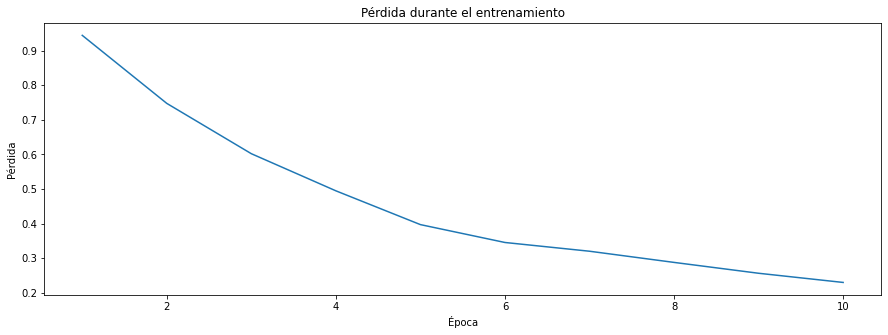

In [ ]:
plt.figure(figsize=(15, 5))
plt.plot(range(1, num_epochs + 1), epoch_losses)
plt.title('Pérdida durante el entrenamiento')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.show()

## 10. Evaluación

Tres piezas propias de PyTorch, que Keras y scikit-learn resuelven por dentro:

- **`model.eval()`** pone la red en modo evaluación. En esta red no cambia nada, pero es obligatorio cuando hay `Dropout` o `BatchNorm`, que se comportan distinto al entrenar y al predecir. Conviene acostumbrarse a escribirlo siempre.
- **`torch.no_grad()`** desactiva el registro de operaciones para autograd. Al predecir no hacen falta gradientes, y desactivarlos ahorra memoria y acelera el cálculo.
- **`torch.max(outputs.data, 1)`** convierte los logits en la clase predicha. Devuelve dos cosas —el valor máximo y su índice— y acá interesa el **índice**, que es el número de clase; por eso el primer valor se descarta con `_`. El `1` indica que el máximo se busca por fila.

El conteo es manual: `total` acumula cuántas muestras se vieron y `correct` cuántas se acertaron, comparando predicción contra etiqueta. `.sum().item()` suma los aciertos del lote y extrae el número.

**Resultado: 96,67% de exactitud** — 29 aciertos sobre 30. El error está en una sola flor, casi con seguridad en la frontera entre *versicolor* y *virginica*, que son las dos clases que se solapan en Iris.

In [ ]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        outputs = model(x_batch)
        _, predict = torch.max(outputs.data, 1)
        total += y_batch.size(0)
        correct += (predict == y_batch).sum().item()

accuracy = 100 * correct / total
print(f'Accuracy: {accuracy:.2f}%')

Accuracy: 96.67%


---

## Resumen

### El flujo de PyTorch, de punta a punta

| # | Paso | Código |
|:--:|---|---|
| 1 | Conseguir y partir los datos | `load_iris()`, `train_test_split(...)` |
| 2 | Escalar, ajustando solo con train | `StandardScaler().fit_transform(X_train)` |
| 3 | Convertir a tensores con el tipo correcto | `torch.tensor(..., dtype=torch.float32)` / `long` |
| 4 | Agrupar y servir por lotes | `TensorDataset` + `DataLoader` |
| 5 | Definir la red | clase que hereda de `nn.Module`, con `__init__` y `forward` |
| 6 | Elegir pérdida y optimizador | `nn.CrossEntropyLoss()`, `optim.Adam(...)` |
| 7 | Entrenar | bucle: `zero_grad` → `forward` → `loss` → `backward` → `step` |
| 8 | Evaluar | `model.eval()` + `torch.no_grad()` + `torch.max` |

### Los cinco pasos del bucle, que son el corazón de todo

```python
optimizer.zero_grad()             # 1. limpiar gradientes acumulados
outputs = model(x_batch)          # 2. forward
loss = criterion(outputs, y_batch)# 3. calcular el error
loss.backward()                   # 4. backpropagation
optimizer.step()                  # 5. actualizar los pesos
```

Omitir cualquiera de los cinco rompe el entrenamiento, y **ninguno da error**: la red simplemente no aprende. Sin `zero_grad` los gradientes se acumulan; sin `step` se calculan pero no se aplican.

### Comparación con lo que ya sabíamos

| | `MLPClassifier` (módulo 06) | PyTorch (acá) |
|---|---|---|
| Arquitectura | `hidden_layer_sizes=(64, 128)` | tres `nn.Linear` en una clase |
| Activación | `activation='relu'` | `torch.relu()` en `forward` |
| Pérdida | log-loss, implícita | `nn.CrossEntropyLoss()`, explícita |
| Optimizador | `solver='adam'` | `optim.Adam(..., lr=0.001)` |
| Escalado | había que hacerlo aparte | igual, con `StandardScaler` |
| Entrenamiento | `.fit()` | bucle de 5 pasos escrito a mano |
| Líneas de código | ~3 | ~30 |

El resultado sobre Iris es prácticamente el mismo (**96,67%** acá contra el 96,45% que daba el MLP grande de scikit-learn). Con un problema tan simple, PyTorch no aporta ventaja de rendimiento: aporta **control**, y eso recién se vuelve necesario con CNNs, RNNs y arquitecturas a medida — que es a donde va el resto del módulo.

### Detalles que conviene retener

- **La última capa no lleva softmax** porque `CrossEntropyLoss` ya lo aplica. Ponerlo dos veces es un error clásico.
- **Las etiquetas van en `long`**, no one-hot: es distinto de Keras.
- **`float32` para las features**: NumPy entrega `float64` y eso da error de tipo.
- **`.item()`** para extraer números de un tensor y no arrastrar el grafo de gradientes.
- **`torch.no_grad()`** al evaluar, siempre.

### Lo que hay que arreglar de este recurso

Agregar `epoch_losses.append(running_loss / len(train_loader))` dentro del bucle de épocas. Sin esa línea la celda del gráfico falla; el gráfico guardado en el notebook proviene de otra versión del código.